In [3]:
#CHANCE OF ADMISSION

#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

#Load Dataset
url = "https://raw.githubusercontent.com/ybifoundation/Dataset/main/Admission%20Chance.csv"
df = pd.read_csv(url)

df.head()

#Basic Information
print("Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()

Shape: (400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4    SOP               400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


,0
Serial No,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


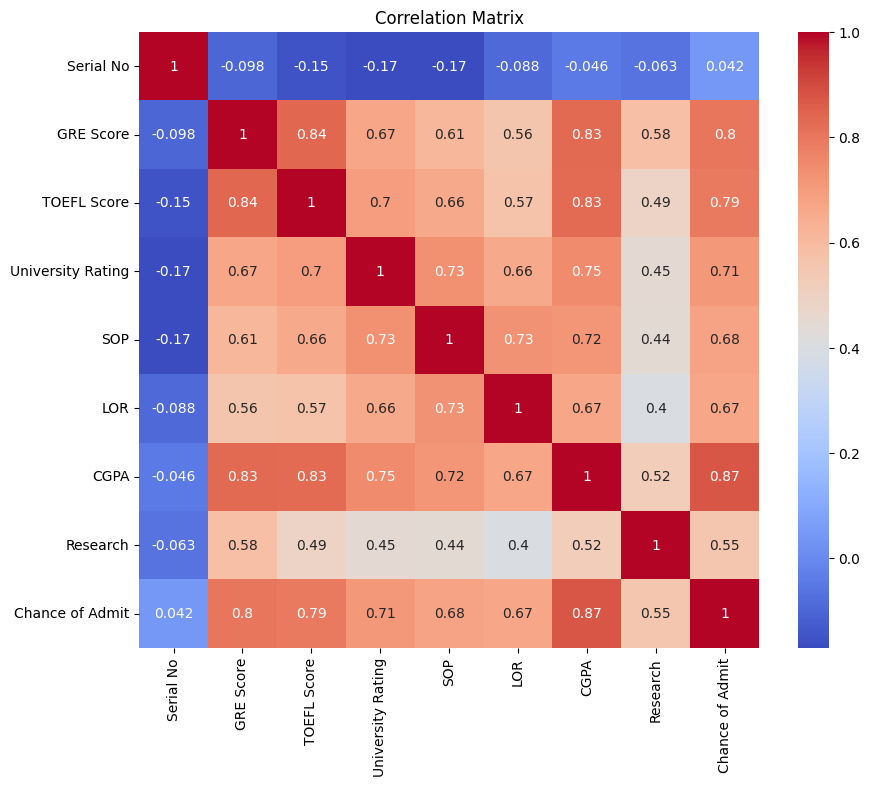

Linear Regression R2 Score: 0.8212241793299224
MSE: 0.004616592264723968
RMSE: 0.06794550952582494


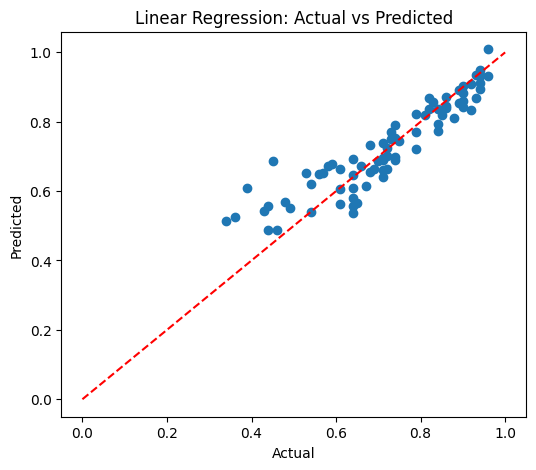

Polynomial R2 Score: 0.8203801767740997
Ridge R2 Score: 0.8209696604507664
Lasso R2 Score: 0.800657075918638


,Model,R2 Score
0,Linear,0.821224
2,Ridge,0.820970
1,Polynomial,0.820380
3,Lasso,0.800657


In [4]:
#Remove Unnecessary Column
df = df.drop(columns=['Serial No.'], errors='ignore')

#Rename Columns (Optional but Cleaner)
df.columns = df.columns.str.strip()

#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Define Features and Target
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL 1: Linear Regression (Baseline)
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

#Actual vs Predicted Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

#MODEL 2: Polynomial Regression (Degree = 2)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

print("Polynomial R2 Score:", r2_score(y_test, y_pred_poly))

#MODEL 3: Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R2 Score:", r2_score(y_test, y_pred_ridge))

#MODEL 4: Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso R2 Score:", r2_score(y_test, y_pred_lasso))

#Model Comparison
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results.sort_values(by="R2 Score", ascending=False)
